# Learning to solve a nonlinear ODE reference tracking problem with robustness

We follow the Neuromancer `examples/control/Part_3_ref_tracking_ODE` example and use the [Differentiable predictive control (DPC) method](https://www.sciencedirect.com/science/article/pii/S0959152422000981) to learn a parametric neural control policy for reference tracking of a nonlinear ordinary differential equation (ODE).

Example adopted from: https://apmonitor.com/do/index.php/Main/LevelControl

In this notebook, we train controllers with and without robustness regularization, and report Lipschitz estimates of the trained controllers as a robustness proxy. Details of the system, objective, and regularizers are given later.


## NeuroMANCER, eclipse-nn and Dependencies

### Install (Colab only)
Skip this step when running locally.

In [ ]:
!pip install neuromancer

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

In [ ]:
!pip install eclipse-nn

In [1]:
import torch
import torch.nn as nn
import numpy as np
from torch.func import vmap, jacrev
import copy

from neuromancer import Node
import neuromancer.psl as psl
from neuromancer.system import System, SystemPreview
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.dynamics import ode, integrators
from neuromancer.plot import pltCL, pltPhase

import warnings
warnings.filterwarnings("ignore")

In [2]:
from eclipse_nn.LipConstEstimator import LipConstEstimator

# System model 

Lets consider the following system of two connected tanks controlled by a single pump and a two way valve.
The system is a simplified model of a [pumped-storage hydroelectricity](https://en.wikipedia.org/wiki/Pumped-storage_hydroelectricity) which is a type of hydroelectric energy storage used by electric power systems for [load balancing](https://en.wikipedia.org/wiki/Load_balancing_(electrical_power). 

**System schematics**:  
<img src="../figs/two_tank_level.png" width="250">  

**System model**:  
The system dynamics is defined by following nonlinear ordinary differential equations (ODEs):
$$
 \frac{dx_1}{dt} = c_1 (1.0 - v)  p - c_2  \sqrt{x_1}  \\  
 \frac{dx_2}{dt}  = c_1 v p + c_2  \sqrt{x_1} - c_2 \sqrt{x_2}
$$  
With system states $x_1$, and $x_2$ representing liquid levels in tank 1 and 2, respectively. Control actions are pump modulation $p$, and valve opening $v$. The ODE system is parametrized by inlet and outlet valve coefficients $c_1$ and $c_2$, respectively.


**Control ojective**:   
The objective is to control the tank levels into desired reference values by modulating the pump and valve control actions.

System model and image adopted from: https://apmonitor.com/do/index.php/Main/LevelControl

In [3]:
# ground truth system model
gt_model = psl.nonautonomous.TwoTank()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = 0
umax = 1.
xmin = 0
xmax = 1.

# Differentiable Predictive Control 

Next we show how to solve the corresponding parametric optimal control using the [DPC method](https://www.sciencedirect.com/science/article/pii/S0959152422000981) implemented in Neuromancer.

**Schematics of the Differentiable Predictive Control method**:  
<img src="./figs/DPC_simple_method.png" width="600">  

**Neural control policy**:  
The objective of this tutorial is to learn neural control policy $u_k = \pi_\theta(x_k, R)$ to control the tank levels by modulating the pump and valve control actions $u_k = [p_k, v_k]$. The policy takes in the measurements of system states $x_k$ at thime $k$ and desired references $R = [r_k, ..., r_{k+N}]$ over pre-defined horizon $N$. This tutorial shows how to construct a DPC policy in scenarios where future references $[r_{k+1}, ..., r_{k+N}]$ are known and where they are unknown, i.e $[r_{k+1},\dots,r_{k+N}]=r_k$.

**Differentiable system model**:  
The DPC is a model-based policy optimization algorithm, that exploits the differentiability of a wide class of model representations for dynamical systems, including differential equations, state-space models, or various neural network architectures. In this example, we compactly represent the system model by ODE equations  $\text{ODESolve}(f(x^i_k, u^i_k))$  describing the governing dynamics of the controlled system.  

We write the closed-loop system with a neural controller as 
$$
\dot x(t) = f\big(x(t), u(t)\big), \qquad u(t)=\pi_\theta\big(x(t), r(t)\big),
$$
where $r(t)$ is a reference signal.

**Regularization to enhance robustness**:  
We abbreviate $\pi_\theta(x,r)$ to $\pi(x,r)$ for simplicity. Then the neural controller Jacobian is
$$
J_\pi(x) 
= \frac{\partial \pi}{\partial x}(x,r),
\quad \text{with } u=\pi(x,r).
$$

A robustness-promoting regularizer penalizes the squared Frobenius norm
$$
\mathcal{L}_{\mathrm{rob}}(x,r)
= \left\|J_\pi(x)\right\|_F^2
= \left\|
\frac{\partial \pi}{\partial x}(x,r)
\right\|_F^2.
$$




**Differentiable predictive control problem formulation**:    
We learn the explicit neural control policy by solving the following parametric optimal control problem: 
$$
\begin{align}
&\underset{\theta}{\text{minimize}}     &&\mathcal{L}_{\mathrm{dpc}} = \sum_{i=1}^m  \Big( \sum_{k=1}^{N-1} Q_x||x^i_k - r^i_k||_2^2  + Q_N||x^i_N - r^i_N||_2^2 + Q_J \mathcal{L}_{\mathrm{rob}}\left(x^i_k,r^i_k\right) \Big) \\
&\text{subject to}    && x^i_{k+1} =  \text{ODESolve}(f(x^i_k, u^i_k)) \\
&                     && u^i_k = \pi_{\theta}(x^i_k, R^i) \\
&                     && 0 \le x^i_k \le 1 \\
&                     && 0 \le u^i_k \le 1 \\
&                     && x^i_0 \sim \mathcal{P}_{x_0} \\
&                     && R^i \sim  \mathcal{P}_R
\end{align}
$$  
The objective function
1. minimizes the reference tracking error $||x^i_k - r^i_k||_2^2$ over pre-defined prediction horizon $N$ weighted by a scalar $Q_x$, including terminal penalty weighted by $Q_N$.
2. promotes robustness to the control input / trajectory by adding penalty $\mathcal{L}_{\mathrm{rob}}$. 
   
The parametric neural control policy is given by $\pi_{\theta}(x^i_k, R^i)$. The neural control policy is optimized over a problem parameters sampled from the distributions $\mathcal{P}_{x_0}$, and $\mathcal{P}_R$, for state initial conditions, and references, respectively. The parameters $\theta$ are optimized with stochastic gradient descent.

# Training dataset generation

For a training dataset we randomly sample initial conditions of states and sequence of admissible reference trajectories over predefined prediction horizon from given distributions $\mathcal{P}_{x_0}$, and $\mathcal{P}_R$, respectively.

In [4]:
nsteps = 30  # prediction horizon
n_samples = 2000    # number of sampled scenarios

#  sampled references for training the policy
list_refs = [torch.rand(1, 1)*torch.ones(nsteps+1, nref) for k in range(n_samples)]
ref = torch.cat(list_refs)
batched_ref = ref.reshape([n_samples, nsteps+1, nref])
# Training dataset
train_data = DictDataset({'x': torch.rand(n_samples, 1, nx),   # sampled initial conditions of states
                          'r': batched_ref}, name='train')

# sampled references for development set
list_refs = [torch.rand(1, 1)*torch.ones(nsteps+1, nref) for k in range(n_samples)]
ref = torch.cat(list_refs)
batched_ref = ref.reshape([n_samples, nsteps+1, nref])
# Development dataset
dev_data = DictDataset({'x': torch.rand(n_samples, 1, nx),    # sampled initial conditions of states
                        'r': batched_ref}, name='dev')

# torch dataloaders
batch_size = 200
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
                                           collate_fn=train_data.collate_fn,
                                           shuffle=False)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=batch_size,
                                         collate_fn=dev_data.collate_fn,
                                         shuffle=False)

# ODE system model

In the following, we instatiate a continous-time system model together with a 4th order Ruge-Kutta numerical integrator.

In [5]:
# white-box ODE model with no-plant model mismatch
two_tank_ode = ode.TwoTankParam()                   # ODE system equations implemented in PyTorch
two_tank_ode.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
two_tank_ode.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)

# integrate continuous time ODE
integrator = integrators.RK4(two_tank_ode, h=torch.tensor(ts))   # using 4th order runge kutta integrator

# System model and control policy in Neuromancer

Here we construct closed-loop systems as differentiable computational graphs by connecting the system rollout
$$
x_{k+1} = \mathrm{ODESolve}\big(f(x_k, u_k)\big)
$$
with neural control policies. We consider two neural control policies:

1. No reference preview (policy uses only the current reference):
$$
u_k = \pi_{\theta}(x_k, r_k), \qquad
x_{k+1} = \mathrm{ODESolve}\big(f(x_k, \pi_{\theta}(x_k, r_k))\big).
$$

2. With reference preview (policy uses a reference sequence over the horizon):
$$
u_k = \pi_{\theta}(x_k, R), \qquad
x_{k+1} = \mathrm{ODESolve}\big(f(x_k, \pi_{\theta}(x_k, R))\big),
$$
where $R = [r_k, r_{k+1}, \dots, r_{k+N}]$.

Notice the policy input dimension differs between the two cases: $(x_k,r_k)$ versus $(x_k,R)$.

We also compare two training objectives:
1. No robustness regularization: $\mathcal{L}_{\mathrm{dpc}}$ with $Q_J=0$.
2. With controller-Jacobian regularization: $\mathcal{L}_{\mathrm{dpc}}$ with $Q_J>0$.

For the regularized objectives, we use a simple curriculum learning schedule: first train the corresponding unregularized controller to convergence, then warm-start from it and fine-tune using the Jacobian regularizers.

Combining the 2 policy parameterizations (no preview / preview) with the 2 objectives (no / with regularization) above gives 4 training configurations in total.

In [6]:
# symbolic system model
model = Node(integrator, ['x', 'u'], ['x'], name='model')

## Two configurations for neural control policies without and with future references

### No preview of future reference + no regularization:

$\pi_\theta : \mathbb{R}^{n_x\times n_r} \mapsto \mathbb{R}^{n_u}$

In [7]:
# neural net control policy with hard control action bounds
net = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=[32, 32],
                    nonlin=activations['elu'], min=umin, max=umax)
policy = Node(net, ['x', 'r'], ['u'], name='policy')

# closed-loop system model
cl_system = System([policy, model], nsteps=nsteps)
# cl_system.show()

### With preview of future reference + no regularization:

$\pi_\theta : \mathbb{R}^{n_x\times (N+1)\cdot n_r} \mapsto \mathbb{R}^{n_u}$

In [8]:
# neural net control policy with reference preview
net_preview = blocks.MLP_bounds(insize=nx + (nref*(nsteps+1)), outsize=nu, hsizes=[64, 32],
                    nonlin=activations['elu'], min=umin, max=umax)
policy_with_preview = Node(net_preview, ['x', 'r'], ['u'], name='policy_with_preview')

cl_system_preview = SystemPreview([policy_with_preview, model], name='cl_system_preview',
                nsteps=nsteps, preview_keys_map={'r': ['policy_with_preview']}, # reference preview for neural control policy node
                preview_length={'r': nsteps}, pad_mode='replicate') # replicate last sample in the sequence

# Differentiable predictive control objectives and constraints

Here we take advantage of Neuromancer's high level symbolic language to define objective and constraint terms of our optimal control problem.

In [9]:
# variables
x = variable('x')
ref = variable("r")
jcl = variable("Jcl_norm")
j = variable("J_norm")


# objectives
regulation_loss = 5. * ((x == ref) ^ 2)  # target posistion


# constraints
state_lower_bound_penalty = 10.*(x > xmin)
state_upper_bound_penalty = 10.*(x < xmax)
terminal_lower_bound_penalty = 10.*(x[:, [-1], :] > ref-0.01)
terminal_upper_bound_penalty = 10.*(x[:, [-1], :] < ref+0.01)
# objectives and constraints names for nicer plot
regulation_loss.name = 'state_loss'
state_lower_bound_penalty.name = 'x_min'
state_upper_bound_penalty.name = 'x_max'
terminal_lower_bound_penalty.name = 'y_N_min'
terminal_upper_bound_penalty.name = 'y_N_max'


constraints = [
    state_lower_bound_penalty,
    state_upper_bound_penalty,
    terminal_lower_bound_penalty,
    terminal_upper_bound_penalty,
]

# Solving differentiable optimal control problems

Here we put everything together and construct differentiable optimal control problems for both policy parameterizations (no preview / preview). We first train without robustness regularization to obtain baseline controllers, and then warm-start from the corresponding baselines and fine-tune with either controller-Jacobian or closed-loop Jacobian regularization.

## Baseline Problem  (no regularization)

### Problem without reference preview + no regularization:

In [10]:
# list of constraints and objectives
objectives = [regulation_loss]

# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints)

# construct constrained optimization problem without reference preview
# data (x_k, r_k) -> parameters (xi_k) -> policy (u_k) -> dynamics (x_{k+1})
problem = Problem([cl_system], loss)
# problem.show()

### Problem with reference preview + no regularization:

In [11]:
# construct constrained optimization problem with reference preview
# data (x_k, [r_k, ..., r_{k+N}]) -> parameters (xi_k) -> policy (u_k) -> dynamics (x_{k+1})
problem_with_preview = Problem([cl_system_preview], loss)

## Solving the baseline problem
We solve the problems using stochastic gradient descent over pre-defined training data of sampled parameters.

### Without reference preview +  no regularization:

In [12]:
optimizer = torch.optim.AdamW(problem.parameters(), lr=0.01)
#  Neuromancer trainer
trainer = Trainer(
    problem,
    train_loader, dev_loader,
    optimizer=optimizer,
    epochs=200,
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=50, 
)
# Train control policy
best_model = trainer.train()
# load best trained model
trainer.model.load_state_dict(best_model)

epoch: 0  train_loss: 3.159383773803711
epoch: 1  train_loss: 1.7556161880493164
epoch: 2  train_loss: 1.2568228244781494
epoch: 3  train_loss: 1.0233378410339355
epoch: 4  train_loss: 0.8955489993095398
epoch: 5  train_loss: 0.8268642425537109
epoch: 6  train_loss: 0.7868216633796692
epoch: 7  train_loss: 0.7584075331687927
epoch: 8  train_loss: 0.7347937226295471
epoch: 9  train_loss: 0.717839241027832
epoch: 10  train_loss: 0.7035790681838989
epoch: 11  train_loss: 0.6932629346847534
epoch: 12  train_loss: 0.6854739189147949
epoch: 13  train_loss: 0.6802508234977722
epoch: 14  train_loss: 0.6758390665054321
epoch: 15  train_loss: 0.6721322536468506
epoch: 16  train_loss: 0.6684832572937012
epoch: 17  train_loss: 0.6654998660087585
epoch: 18  train_loss: 0.6626723408699036
epoch: 19  train_loss: 0.6600908041000366
epoch: 20  train_loss: 0.6577955484390259
epoch: 21  train_loss: 0.6555737257003784
epoch: 22  train_loss: 0.6537143588066101
epoch: 23  train_loss: 0.6516879796981812
epoc

<All keys matched successfully>

### With reference preview + no regularization:

In [13]:
optimizer_with_preview = torch.optim.Adam(problem_with_preview.parameters(), lr=0.01, weight_decay=0.002)
trainer_with_preview = Trainer(
        problem_with_preview,
        train_loader, dev_loader,
        optimizer=optimizer_with_preview,
        epochs=150,
        train_metric='train_loss',
        eval_metric='dev_loss',
        warmup=5,
        patience=50
    )
# Train control policy with reference preview 
best_model_preview = trainer_with_preview.train()
# Load best model with reference preview
trainer_with_preview.model.load_state_dict(best_model_preview)

epoch: 0  train_loss: 2.750936985015869
epoch: 1  train_loss: 1.6177570819854736
epoch: 2  train_loss: 1.3943709135055542
epoch: 3  train_loss: 1.2491079568862915
epoch: 4  train_loss: 1.1598378419876099
epoch: 5  train_loss: 1.117525339126587
epoch: 6  train_loss: 1.0544906854629517
epoch: 7  train_loss: 1.0130417346954346
epoch: 8  train_loss: 1.0067108869552612
epoch: 9  train_loss: 0.974448025226593
epoch: 10  train_loss: 0.9413964152336121
epoch: 11  train_loss: 0.9415059089660645
epoch: 12  train_loss: 0.9537602663040161
epoch: 13  train_loss: 0.8891056180000305
epoch: 14  train_loss: 0.8433729410171509
epoch: 15  train_loss: 0.8652774095535278
epoch: 16  train_loss: 0.8391852378845215
epoch: 17  train_loss: 0.8319199681282043
epoch: 18  train_loss: 0.8916420936584473
epoch: 19  train_loss: 0.9141111373901367
epoch: 20  train_loss: 0.8944296836853027
epoch: 21  train_loss: 0.8313120603561401
epoch: 22  train_loss: 0.7537857294082642
epoch: 23  train_loss: 0.7493619918823242
epoch

<All keys matched successfully>

## Curriculum Learning with regularizations

In [14]:
# L_rob helper function
def single_sample_policy(policy, x_single, r_single):
    # x_single: [nx], r_single: [nr] or  [(N+1), nr]
    r_single = r_single.reshape(-1)  # works for [nr] and [(N+1), nr]
    out = policy({
        'x': x_single.unsqueeze(0),
        'r': r_single.unsqueeze(0),
    })
    return out['u'].squeeze(0)  # [nu]


# Jacobian of policy w.r.t. x (argnums=1 because inputs are (policy, x, r))
jac_pi_wrt_x = jacrev(single_sample_policy, argnums=1)


def jac_norm(policy, x, r):
    # x: [Batch, nx], r: [Batch, nr] or  [(N+1), nr]
    r = r.reshape(r.shape[0], -1)  # works for [B,nr] and [B,(N+1),nr]
    J_pi = vmap(jac_pi_wrt_x, in_dims=(None, 0, 0))(policy, x, r)  # [Batch, nu, nx]
    j = torch.linalg.norm(J_pi, ord='fro', dim=(-2, -1))                   # [Batch]
    return j.unsqueeze(-1)                                                 # [Batch, 1]



class JacNormCallable:
    def __init__(self, policy):
        self.policy = policy
    def __call__(self, x, r):
        return jac_norm(self.policy, x, r)

### The problem without reference preview + regularization  $L_{\mathrm{rob}}$: 

In [15]:
# warm-start from the trained baseline policy
policy_regNN = copy.deepcopy(policy)

# penalty node
jac_node = Node(JacNormCallable(policy_regNN), ['x', 'r'], ['J_norm'], name='jac')

# closed-loop system that penalizes controller Jacobian
cl_system_regNN = System([policy_regNN, model, jac_node], nsteps=nsteps)

# penalize controller Jacobian
jac_loss = 0.1 * (j == 0.)^2 

objectives_regNN = [regulation_loss, jac_loss]
loss_regNN = PenaltyLoss(objectives_regNN, constraints)

problem_regNN = Problem([cl_system_regNN], loss_regNN)

### The problem with reference preview + regularization  $L_{\mathrm{rob}}$:

In [16]:
# warm-start from the trained baseline policy
policy_pre_regNN = copy.deepcopy(policy_with_preview)

# penalty node
jac_node = Node(JacNormCallable(policy_pre_regNN), ['x', 'r'], ['J_norm'], name='jac')

# closed-loop system that penalizes controller Jacobian
cl_system_pre_regNN = SystemPreview(
    [policy_pre_regNN, model, jac_node],
    nsteps=nsteps,
    preview_keys_map={'r': [policy_pre_regNN.name, jac_node.name]},
    preview_length={'r': nsteps},
    pad_mode='replicate'
)

# penalize controller Jacobian
jac_loss = 0.1 * (j == 0.)^2 


objectives_pre_regNN = [regulation_loss, jac_loss]
loss_pre_regNN = PenaltyLoss(objectives_pre_regNN, constraints)

problem_pre_regNN = Problem([cl_system_pre_regNN], loss_pre_regNN)

## Solving the problem

### Without reference preview +  regularization:

In [17]:
optimizer_regNN = torch.optim.AdamW(problem_regNN.parameters(), lr=0.01)
trainer_regNN = Trainer(
    problem_regNN,
    train_loader, dev_loader,
    optimizer=optimizer_regNN,
    epochs=100,
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=50, 
)

# Train control policy
best_model_regNN = trainer_regNN.train()
# load best trained model
trainer_regNN.model.load_state_dict(best_model_regNN)

epoch: 0  train_loss: 6.071022987365723
epoch: 1  train_loss: 2.3766396045684814
epoch: 2  train_loss: 1.5851733684539795
epoch: 3  train_loss: 1.3785152435302734
epoch: 4  train_loss: 1.308651328086853
epoch: 5  train_loss: 1.2756431102752686
epoch: 6  train_loss: 1.2600390911102295
epoch: 7  train_loss: 1.2530077695846558
epoch: 8  train_loss: 1.2519630193710327
epoch: 9  train_loss: 1.2517168521881104
epoch: 10  train_loss: 1.2481446266174316
epoch: 11  train_loss: 1.2467811107635498
epoch: 12  train_loss: 1.2458652257919312
epoch: 13  train_loss: 1.2486653327941895
epoch: 14  train_loss: 1.2474613189697266
epoch: 15  train_loss: 1.2435382604599
epoch: 16  train_loss: 1.243727445602417
epoch: 17  train_loss: 1.242945909500122
epoch: 18  train_loss: 1.2384358644485474
epoch: 19  train_loss: 1.2332499027252197
epoch: 20  train_loss: 1.2305576801300049
epoch: 21  train_loss: 1.22743821144104
epoch: 22  train_loss: 1.2263777256011963
epoch: 23  train_loss: 1.2248611450195312
epoch: 24  

<All keys matched successfully>

### With reference preview + regularization:

In [18]:
optimizer_pre_regNN = torch.optim.AdamW(problem_pre_regNN.parameters(), lr=0.01)
trainer_pre_regNN = Trainer(
    problem_pre_regNN,
    train_loader, dev_loader,
    optimizer=optimizer_pre_regNN,
    epochs=100,
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=50, 
)
# Train control policy
best_model_pre_regNN = trainer_pre_regNN.train()
# load best trained model
trainer_pre_regNN.model.load_state_dict(best_model_pre_regNN)

epoch: 0  train_loss: 2.038766384124756
epoch: 1  train_loss: 1.1813963651657104
epoch: 2  train_loss: 1.0272682905197144
epoch: 3  train_loss: 0.96656334400177
epoch: 4  train_loss: 0.9504122734069824
epoch: 5  train_loss: 0.9223803281784058
epoch: 6  train_loss: 0.9272018671035767
epoch: 7  train_loss: 0.9166206121444702
epoch: 8  train_loss: 0.9267670512199402
epoch: 9  train_loss: 0.9137002825737
epoch: 10  train_loss: 0.9208911061286926
epoch: 11  train_loss: 0.9098551869392395
epoch: 12  train_loss: 0.9232833981513977
epoch: 13  train_loss: 0.8974188566207886
epoch: 14  train_loss: 0.9126189947128296
epoch: 15  train_loss: 0.9204767942428589
epoch: 16  train_loss: 0.8921645283699036
epoch: 17  train_loss: 0.909717857837677
epoch: 18  train_loss: 0.9053764343261719
epoch: 19  train_loss: 0.8849849700927734
epoch: 20  train_loss: 0.9371091723442078
epoch: 21  train_loss: 0.8918536901473999
epoch: 22  train_loss: 0.8987115025520325
epoch: 23  train_loss: 0.8774813413619995
epoch: 24

<All keys matched successfully>

# Evaluate best model on a system rollout

In [19]:
# Creating the test data
nsteps = 1000
step_length = 250
# generate reference
np_refs = psl.signals.step(nsteps + 1, 1, min=xmin, max=xmax, randsteps=4, rng=np.random.default_rng(20))
R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps+1, 1)
torch_ref = torch.cat([R, R], dim=-1)
# generate initial data for closed loop simulation
data = {'x': torch.rand(1, 1, nx, dtype=torch.float32),
        'r': torch_ref}

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])

## Evaluation of best model without reference preview

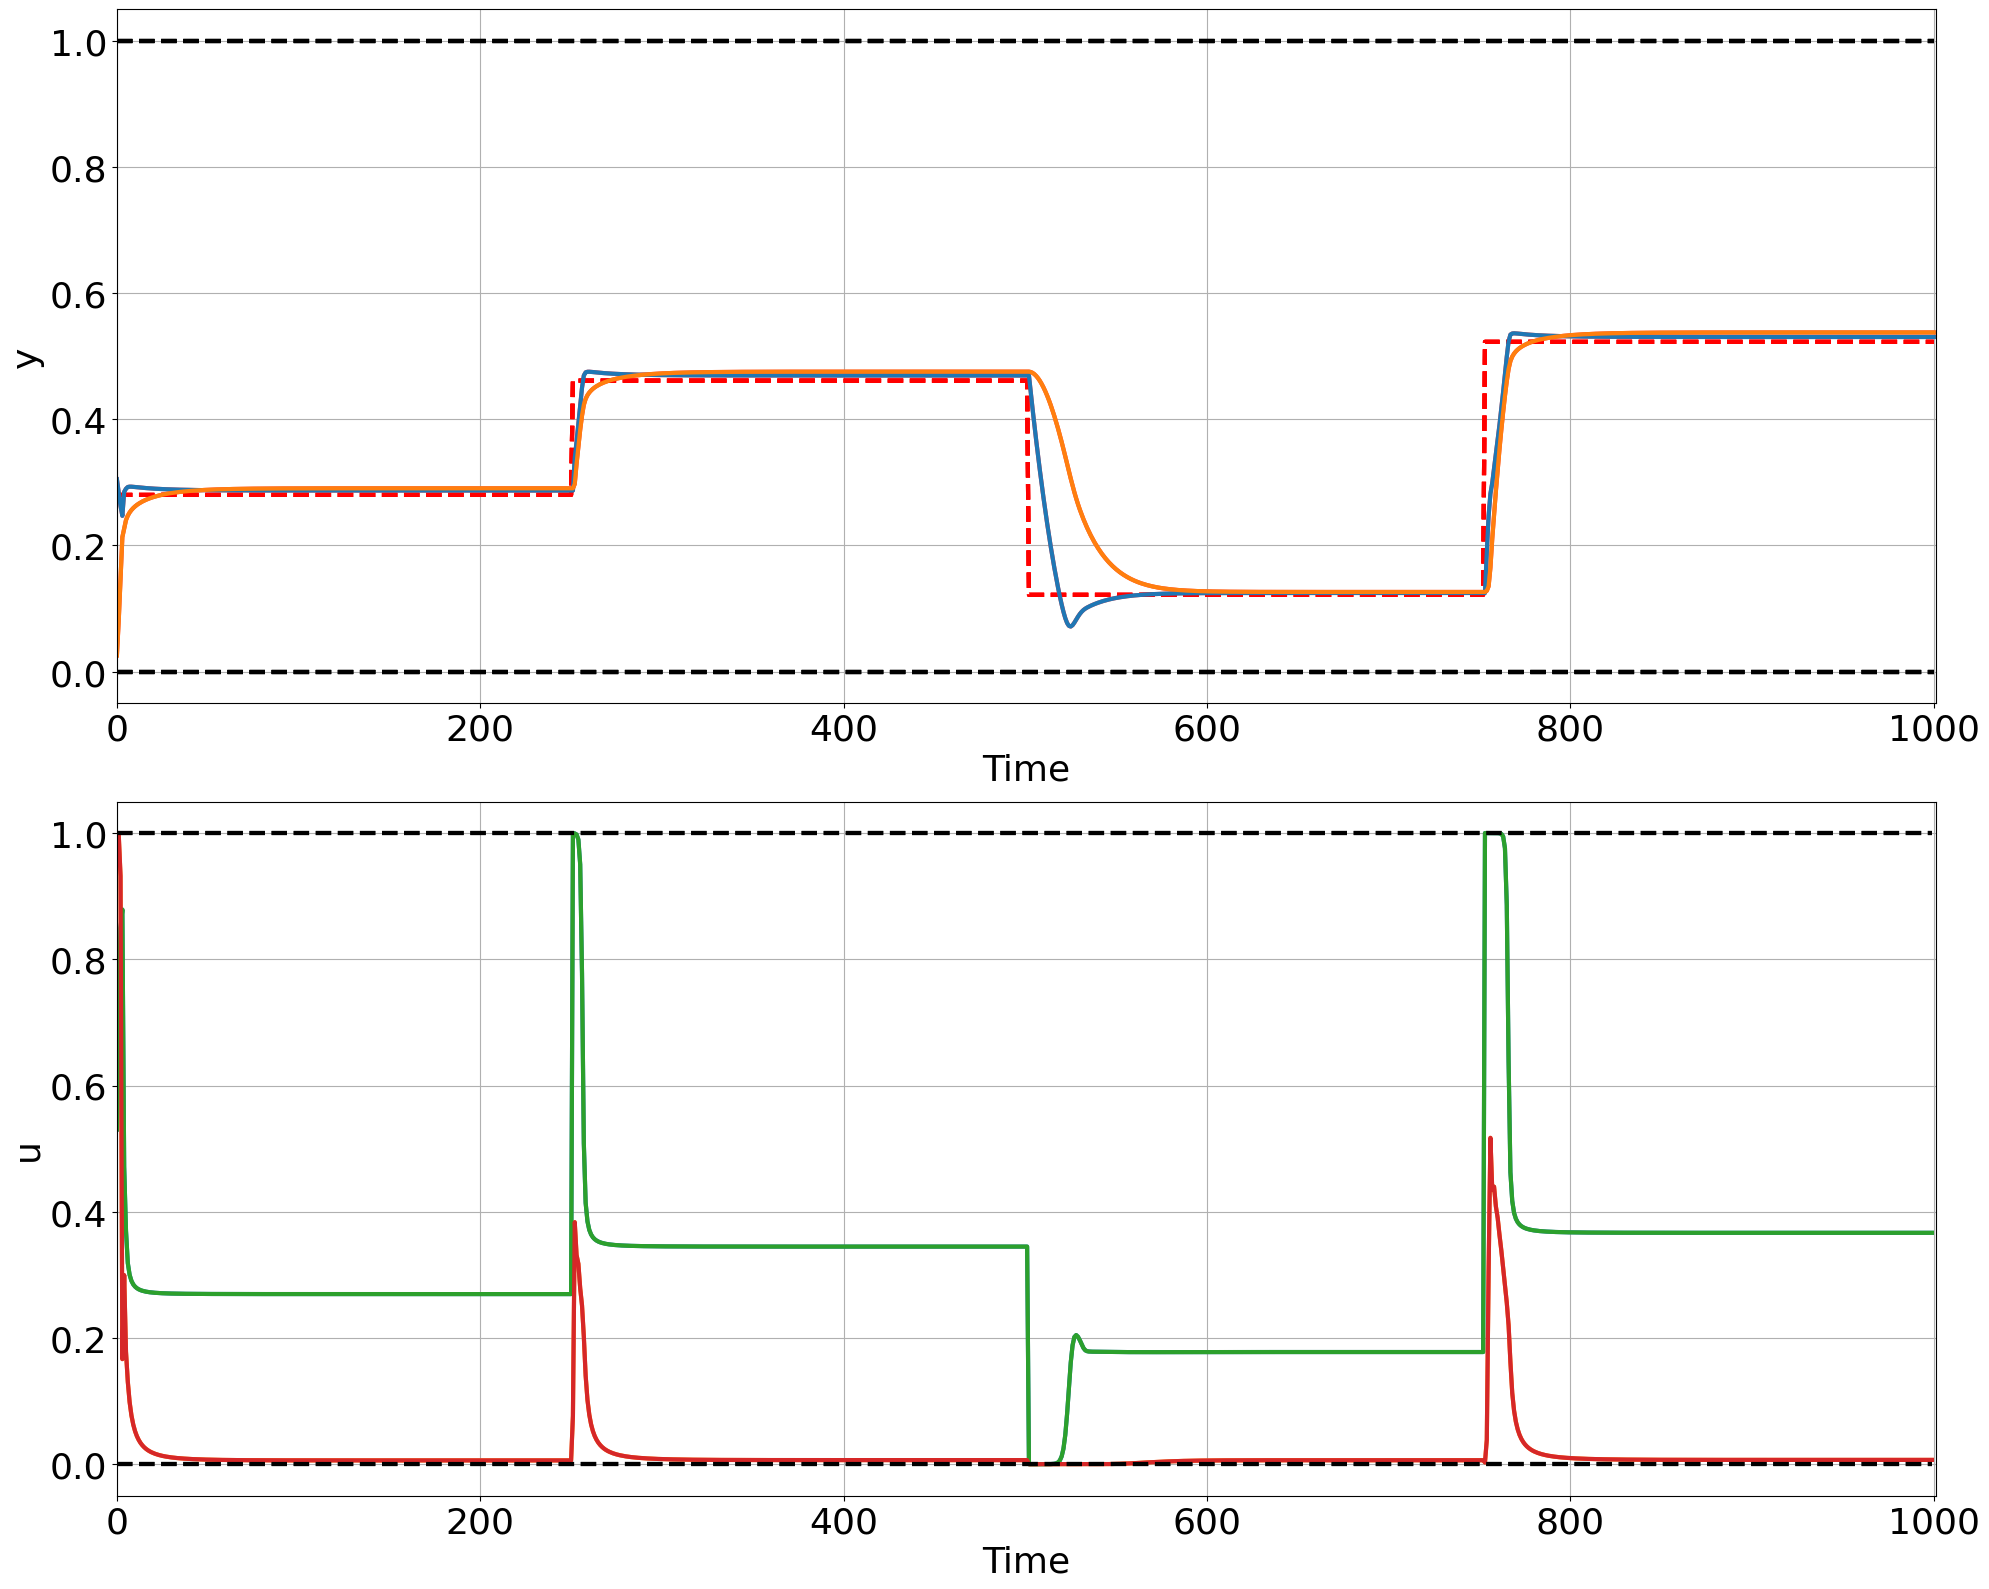

<Figure size 640x480 with 0 Axes>

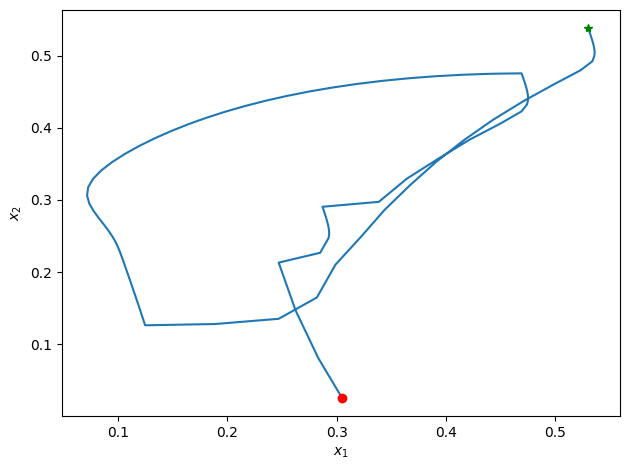

<Figure size 640x480 with 0 Axes>

In [20]:
cl_system.nsteps = nsteps
# perform closed-loop simulation
trajectories = cl_system(data)
# plot closed loop trajectories
pltCL(Y=trajectories['x'].detach().reshape(nsteps + 1, nx),
      R=trajectories['r'].detach().reshape(nsteps + 1, nref),
      U=trajectories['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax,
      figname='cl.png')
# plot phase portrait
pltPhase(X=trajectories['x'].detach().reshape(nsteps + 1, nx),
         figname='phase.png')

## Evaluation of best model without reference preview and with regularizer

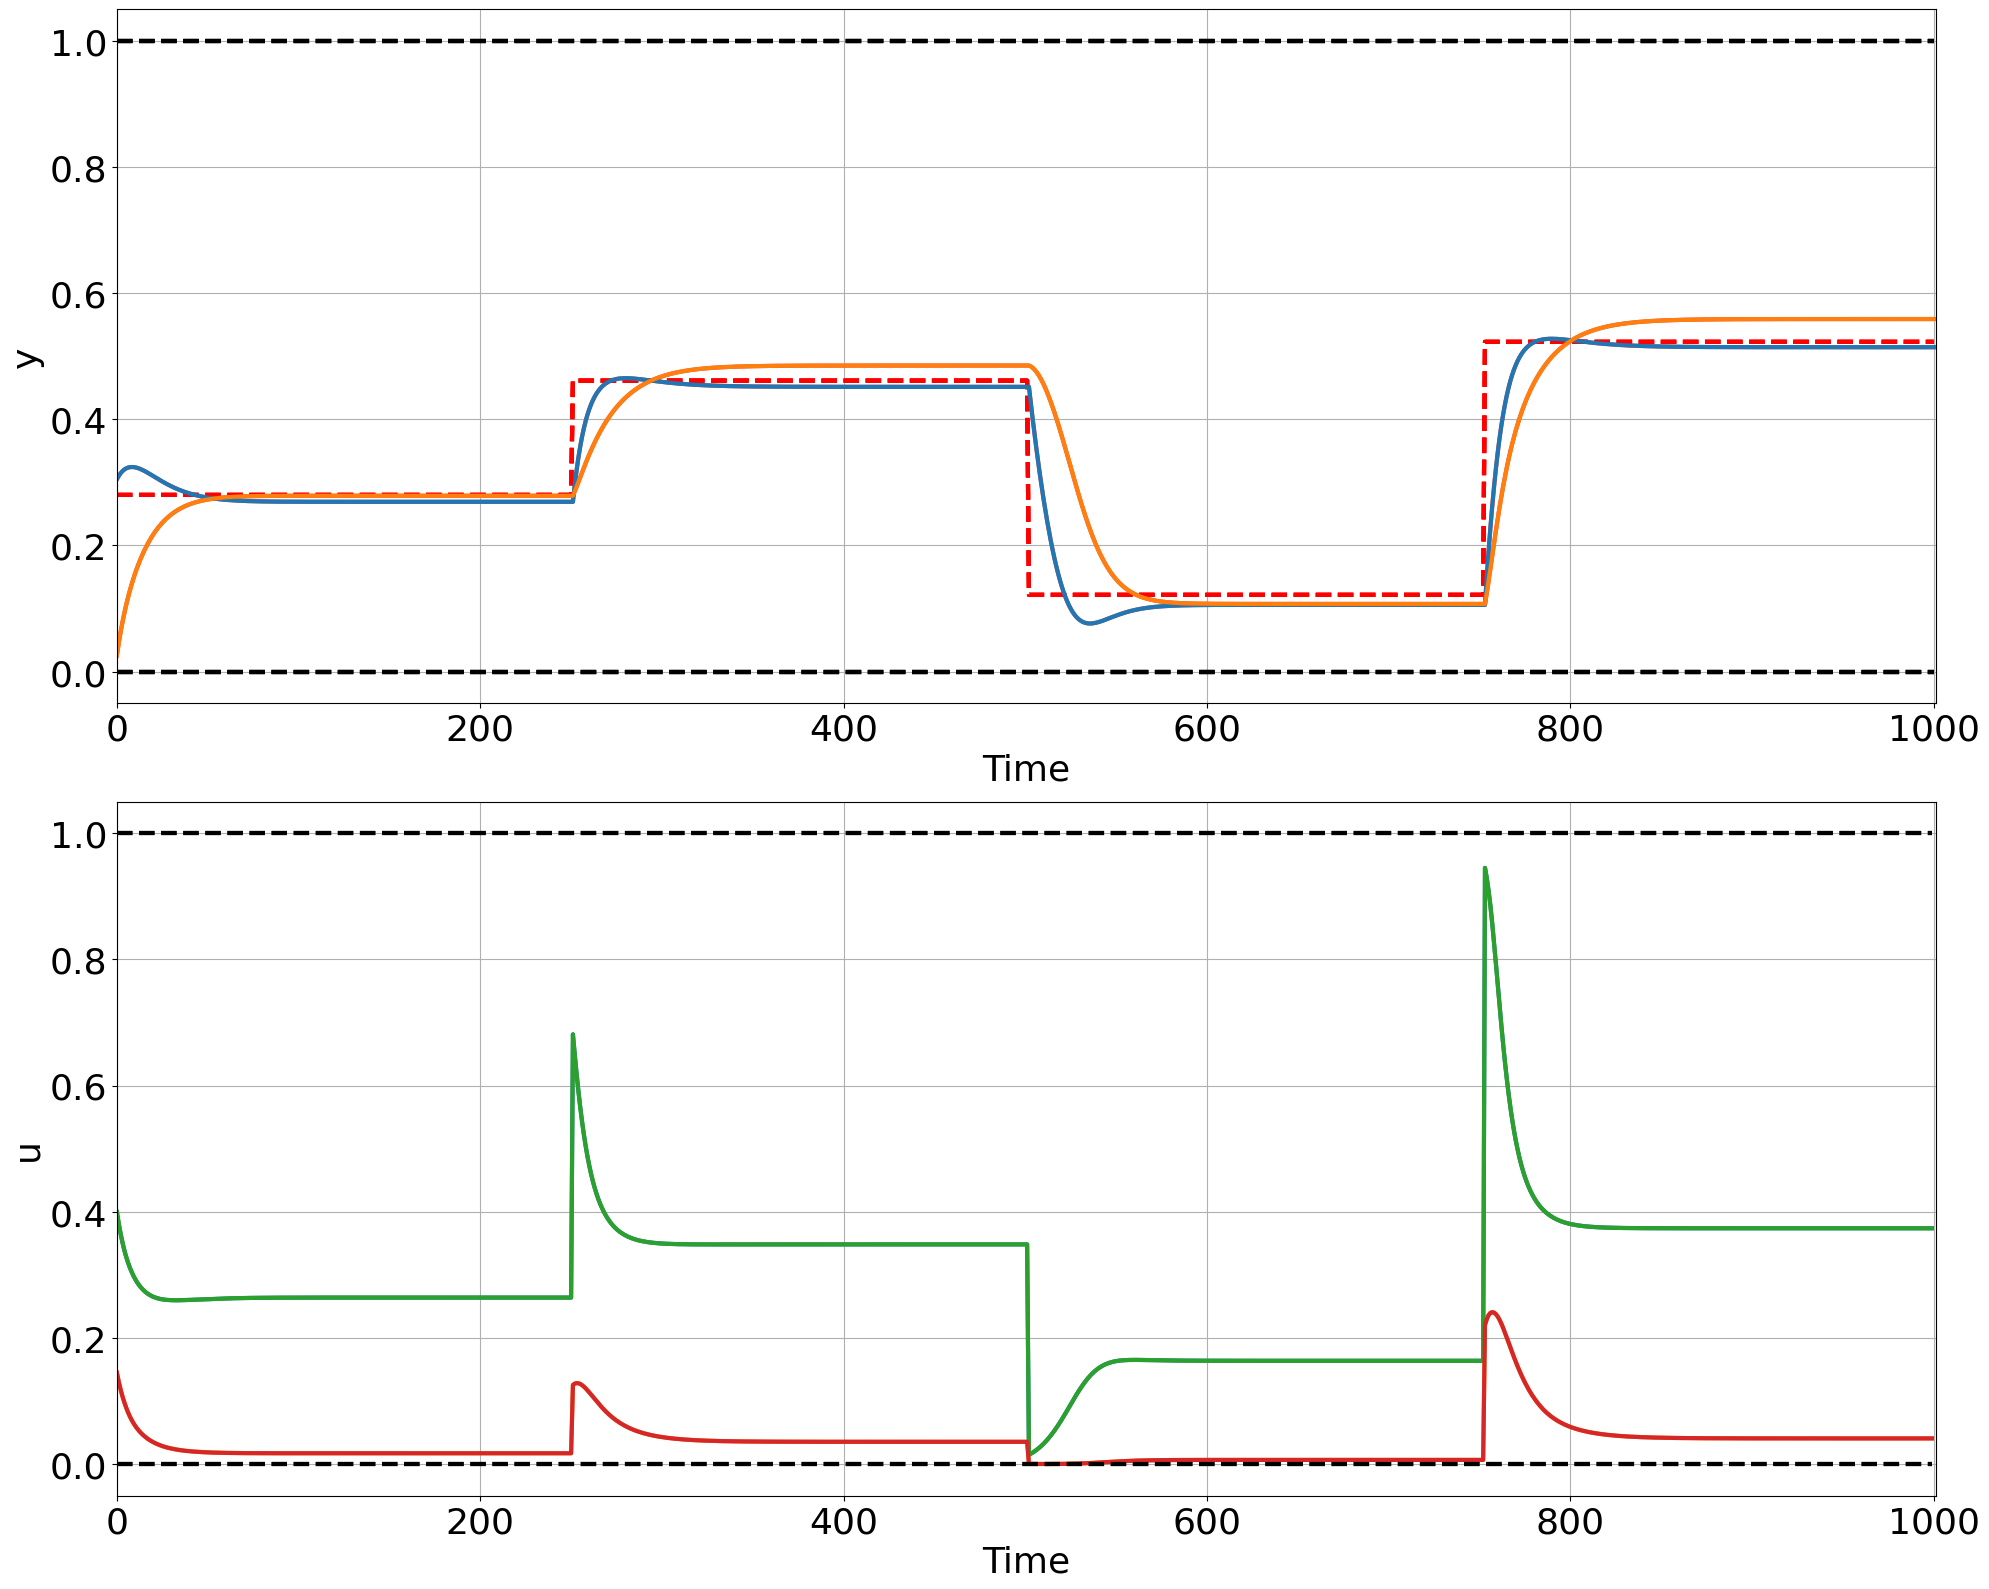

<Figure size 640x480 with 0 Axes>

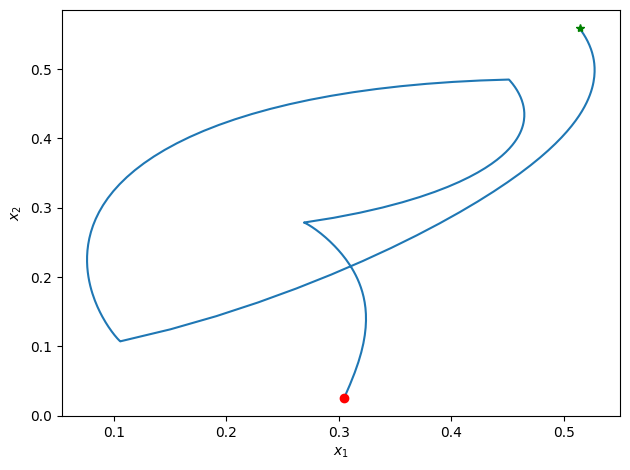

<Figure size 640x480 with 0 Axes>

In [21]:
# Applying curriculum learning
cl_system_regNN.nsteps = nsteps
# perform closed-loop simulation
trajectories = cl_system_regNN(data)
# plot closed loop trajectories
pltCL(Y=trajectories['x'].detach().reshape(nsteps + 1, nx),
      R=trajectories['r'].detach().reshape(nsteps + 1, nref),
      U=trajectories['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax,
      figname='cl.png')
# plot phase portrait
pltPhase(X=trajectories['x'].detach().reshape(nsteps + 1, nx),
         figname='phase.png')

## Evaluation of best model with reference preview

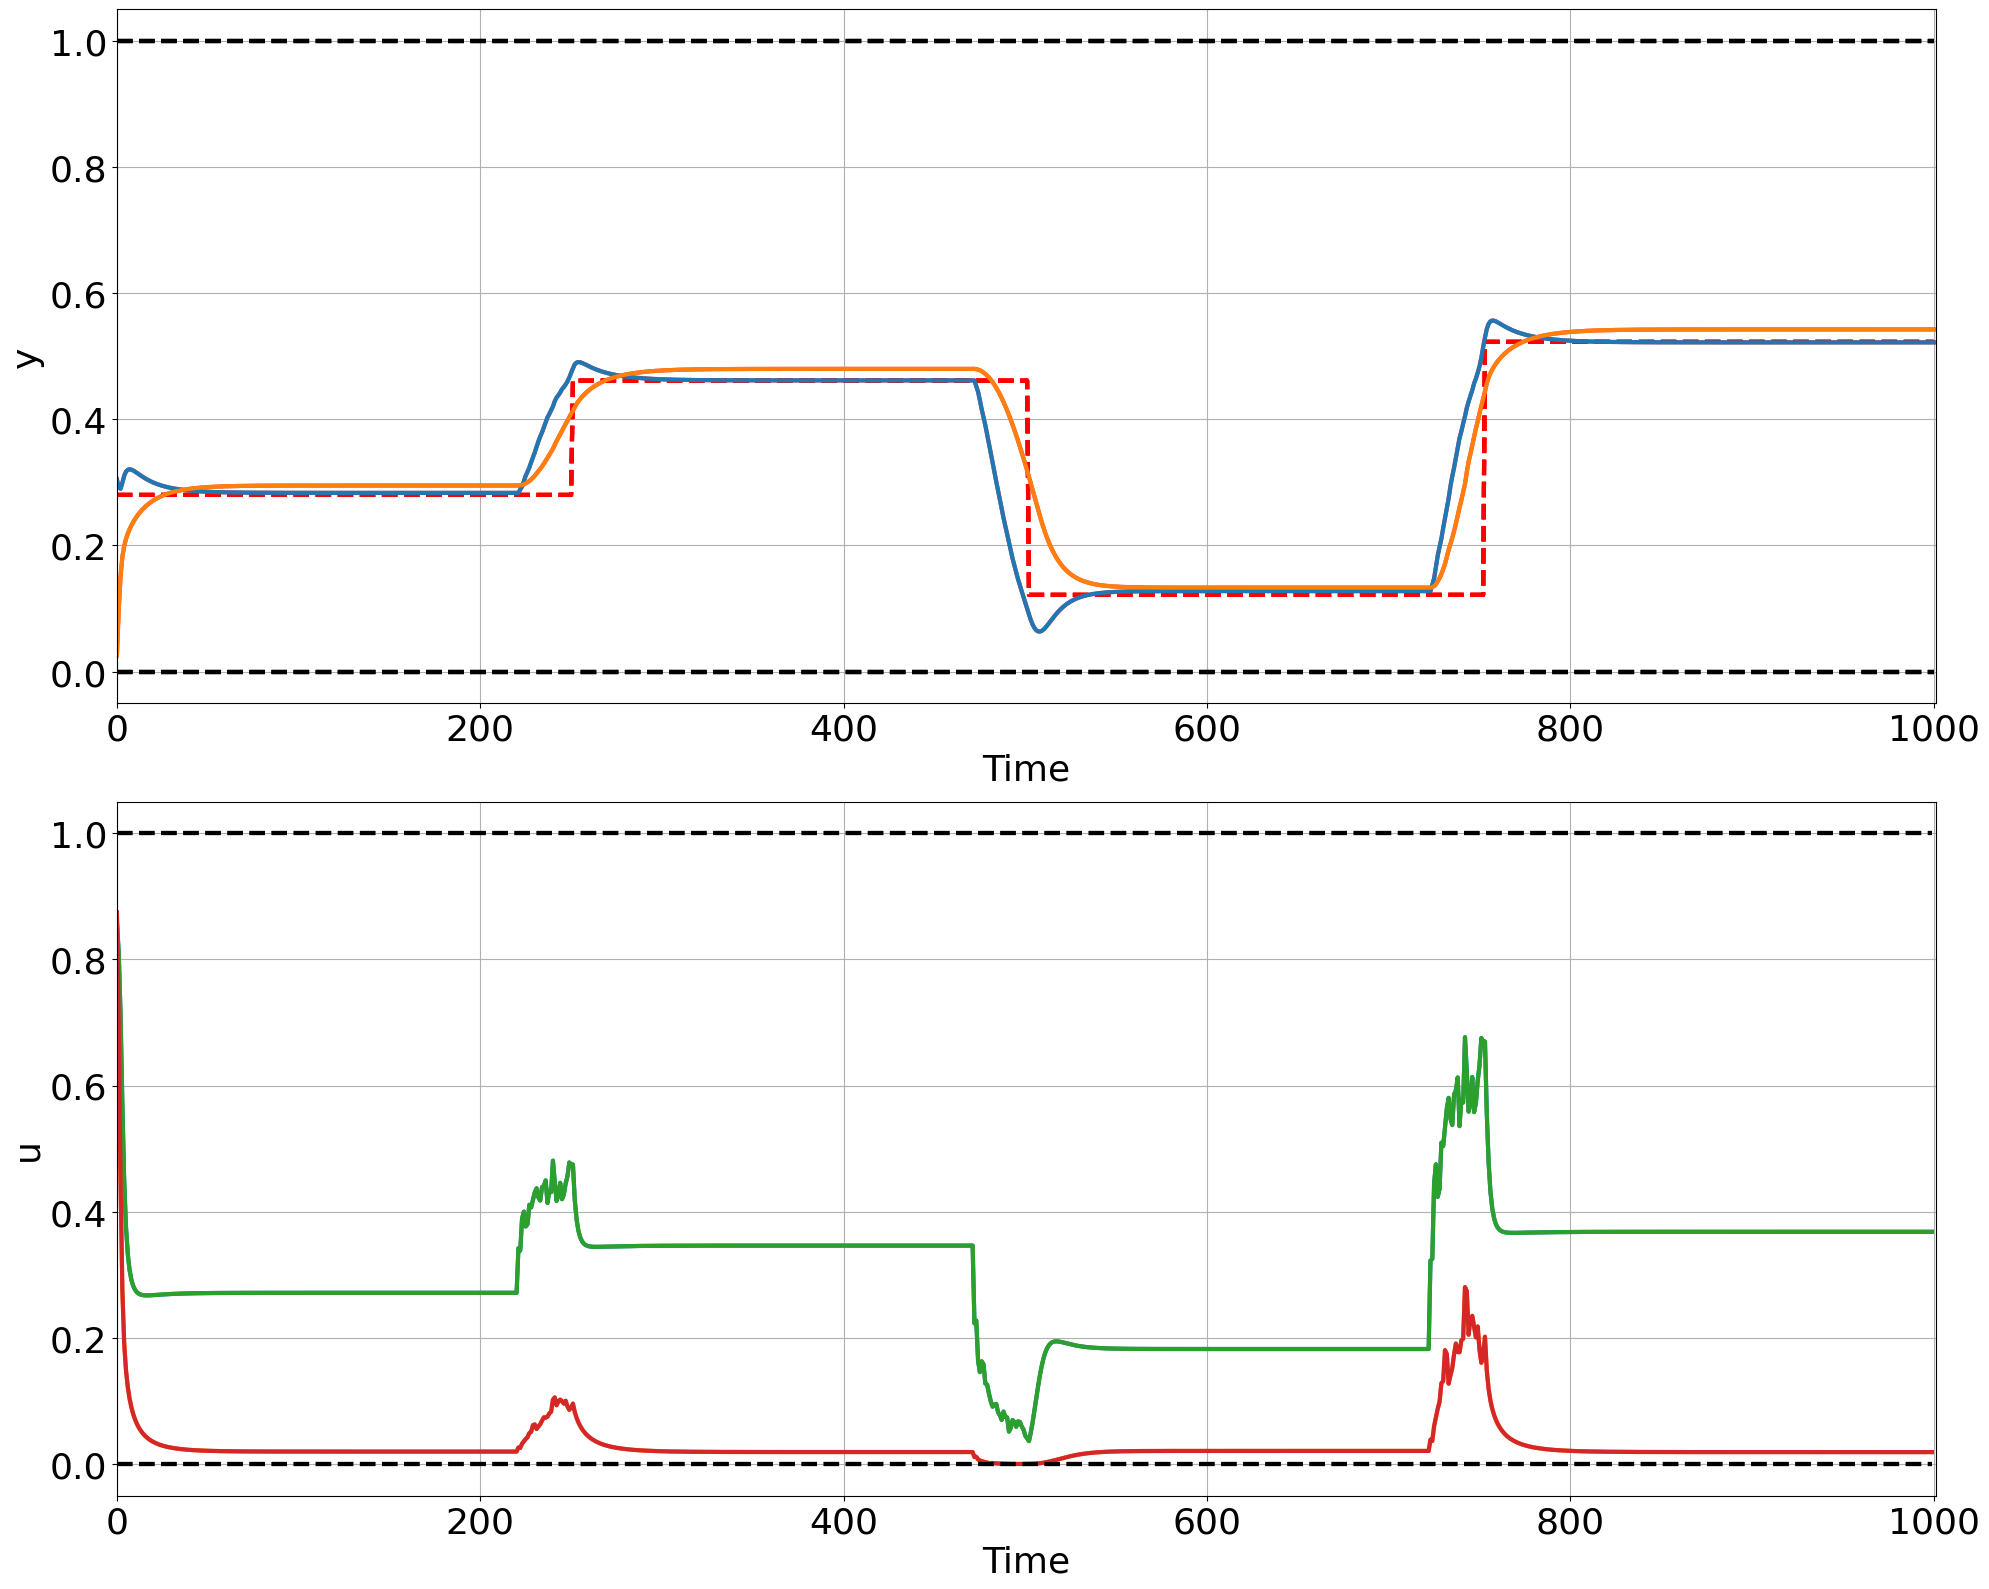

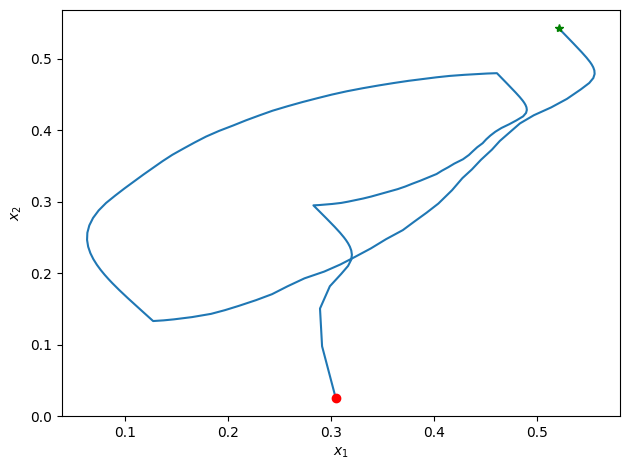

In [22]:
# closed-loop simulation with reference preview
cl_system_preview.nsteps = nsteps
trajectories_with_preview = cl_system_preview(data)
pltCL(Y=trajectories_with_preview['x'].detach().reshape(nsteps + 1, nx),
        R=trajectories_with_preview['r'].detach().reshape(nsteps + 1, nref),
        U=trajectories_with_preview['u'].detach().reshape(nsteps, nu),
        Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)
pltPhase(X=trajectories_with_preview['x'].detach().reshape(nsteps + 1, nx))

## Evaluation of best model with reference preview and with regularizer

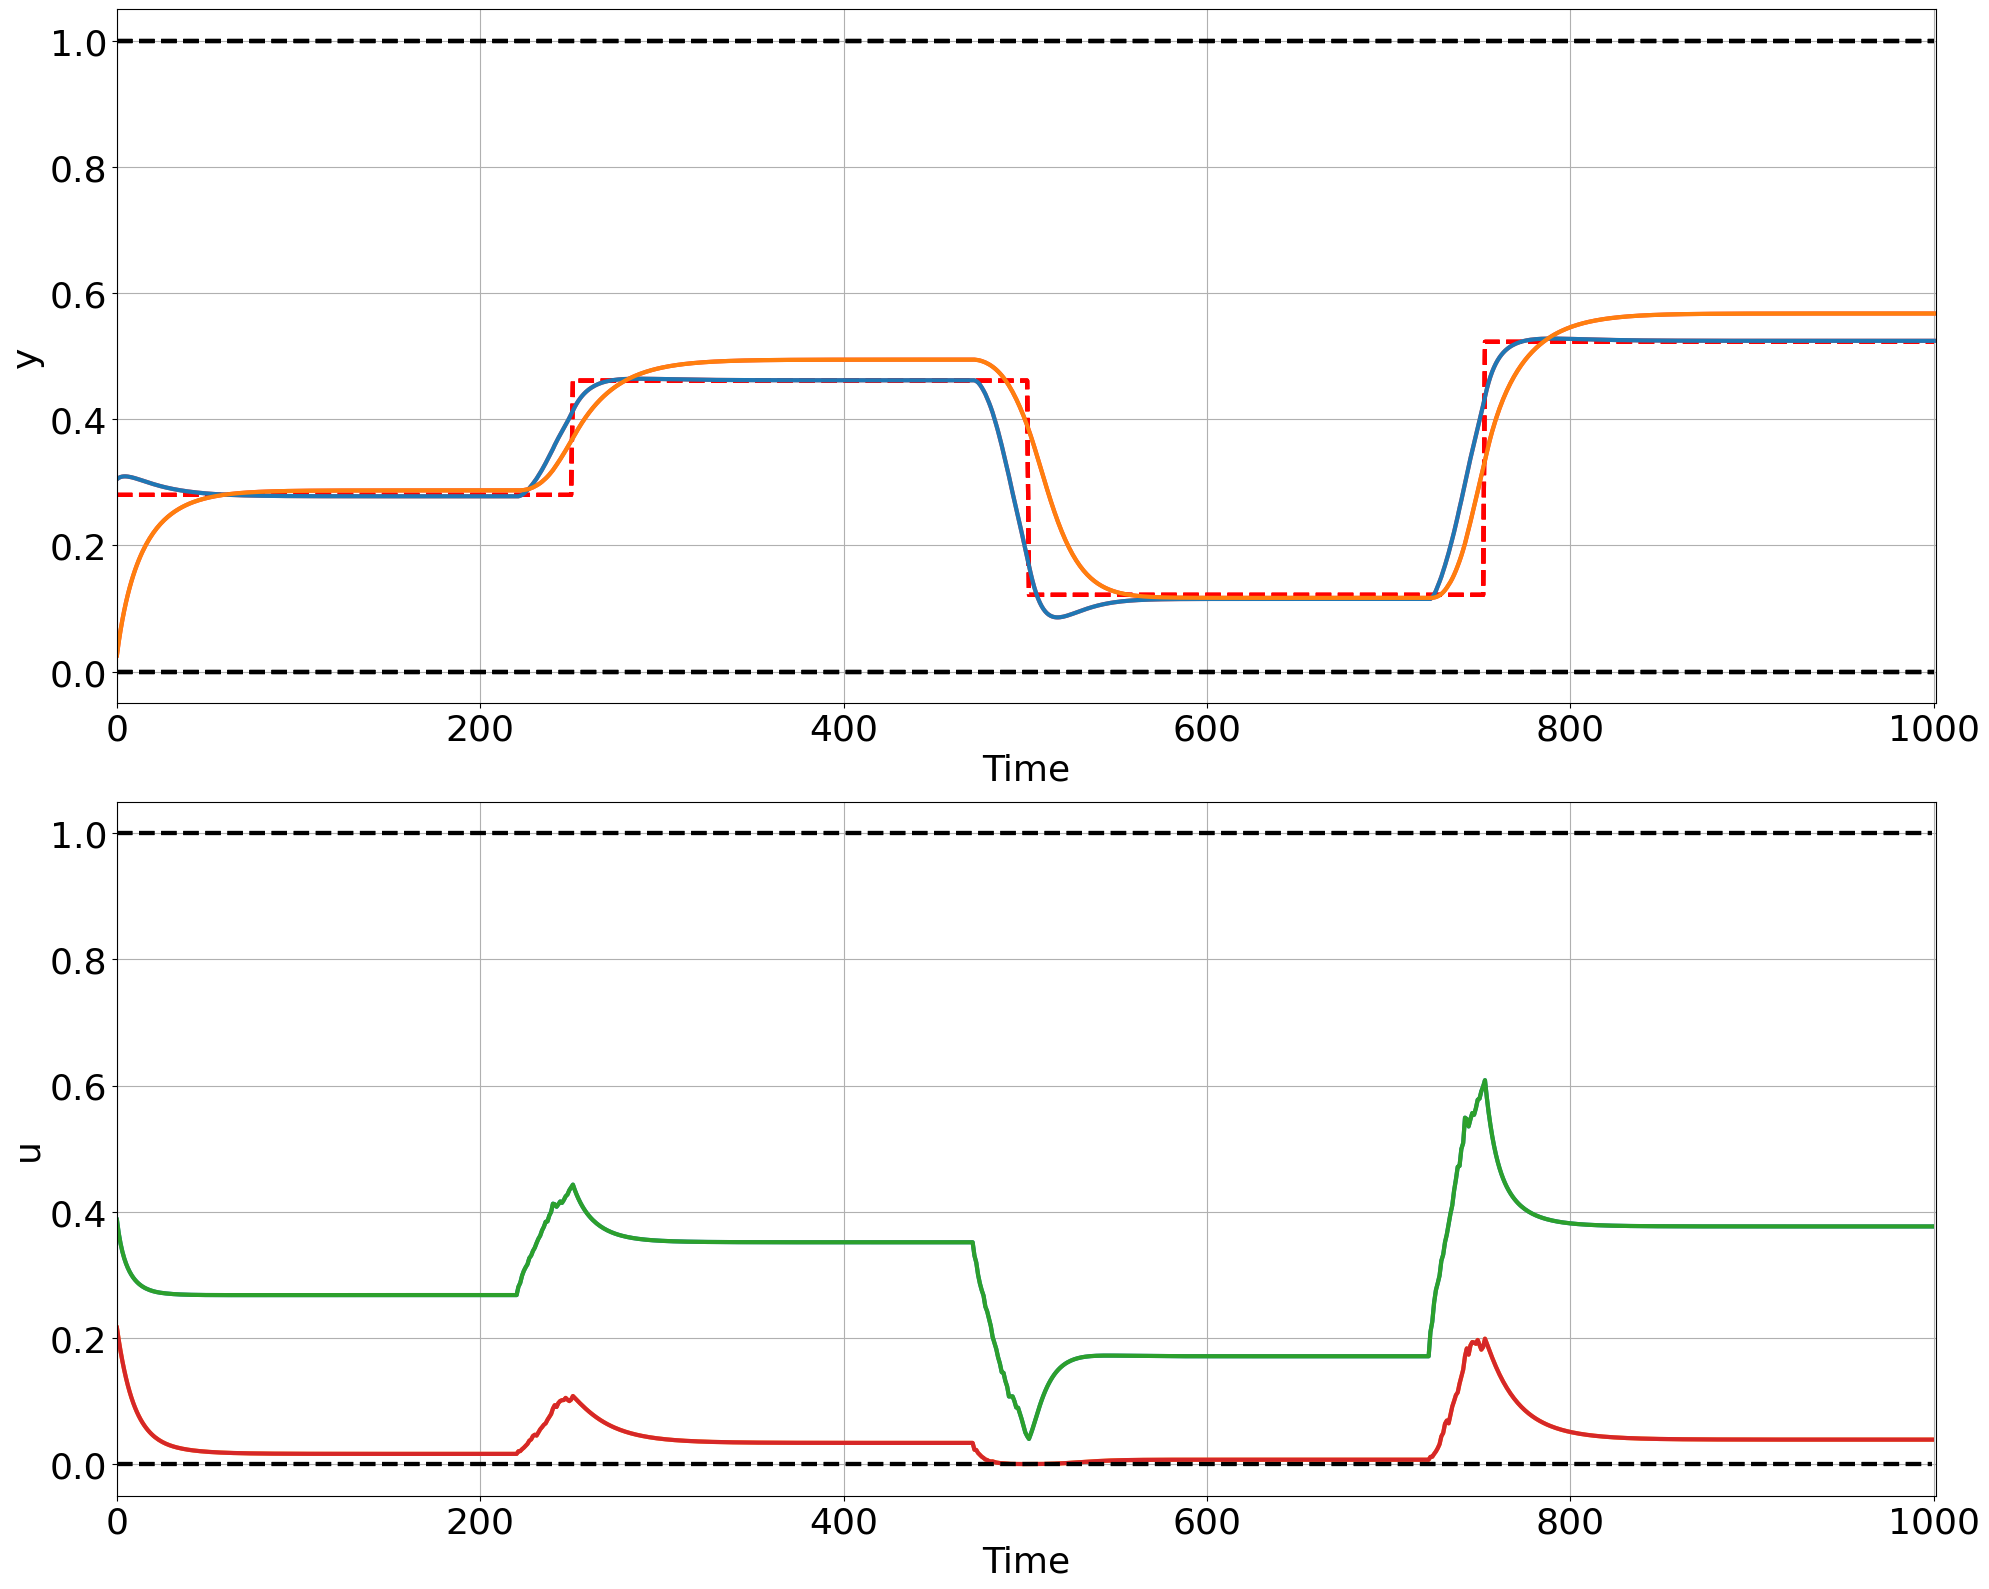

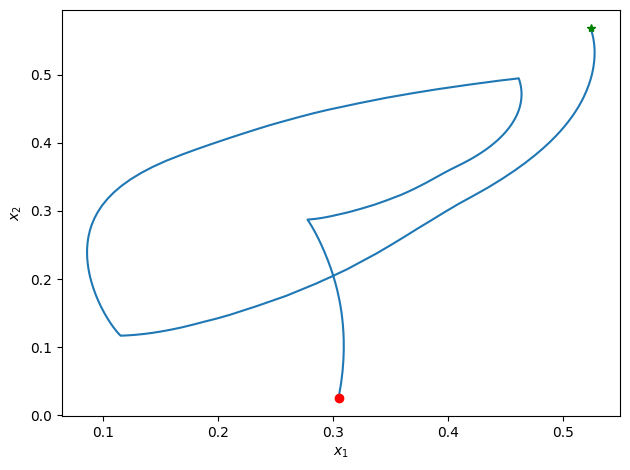

In [23]:
# closed-loop simulation with reference preview
cl_system_pre_regNN.nsteps = nsteps
trajectories_pre_regNN = cl_system_pre_regNN(data)
pltCL(Y=trajectories_pre_regNN['x'].detach().reshape(nsteps + 1, nx),
        R=trajectories_pre_regNN['r'].detach().reshape(nsteps + 1, nref),
        U=trajectories_pre_regNN['u'].detach().reshape(nsteps, nu),
        Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)
pltPhase(X=trajectories_pre_regNN['x'].detach().reshape(nsteps + 1, nx))

# Testing the robustness of learned model by estimating Lipschitz constant of the neural controller $\pi_\theta(x,r)$
Now we estimate the Lipschitz constant of all the 6 neural controllers u=NN(x). Note that the activation functions used in the 6 neural models are `ELU`, whose slope bound is $[0,1]$. This matches the default setting in ECLipsE. If needed, user-specified slope bounds can also be provided to accommodate other activation functions.

In [24]:
# helper function for extracting weights from the trained NNs
import re

def extract_eclipse_tensors(model_dict, device='cpu'):
    """
    Extracts weights from a Neuromancer state_dict as a list of Double-Precision Tensors
    suitable for eclipse-nn input.
    
    Args:
        model_dict (dict): The state_dict from best_model (e.g., best_model_reg)
        device (str): 'cpu' or 'cuda'.
    
    Returns:
        weights (list of torch.Tensor): [W1, W2, ..., Wn] in float64
    """
    layer_weights = {}
    
    # Regex to capture layer index from keys like 'nodes.0...linear.0.weight'
    pattern = re.compile(r"linear\.(\d+)\.(weight)")
    
    for key, val in model_dict.items():
        match = pattern.search(key)
        if match:
            layer_idx = int(match.group(1))
            
            # CRITICAL FIX: Add .double() to match eclipse-nn's float64 requirement
            w_tensor = val.detach().clone().double().to(device)
            
            layer_weights[layer_idx] = w_tensor

    # Sort keys to ensure order: Layer 0 -> Layer 1 -> ...
    sorted_indices = sorted(layer_weights.keys())
    
    weights_list = [layer_weights[i] for i in sorted_indices]
    
    print(f"Extracted {len(weights_list)} weight matrices (float64).")
    return weights_list

In [25]:
Ws = extract_eclipse_tensors(best_model, device='cpu')
est = LipConstEstimator(weights=Ws)
lip = est.estimate(method="ECLipsE")   
print("Lipschitz estimate for the neural controller trained with no preview and without regularization:", lip)

Extracted 3 weight matrices (float64).
Optimization reached a boundary solution. Falling back to ECLipsE-Fast for the current stage.
Lipschitz estimate for the neural controller trained with no preview and without regularization: tensor(36.6597, dtype=torch.float64)


In [26]:
Ws = extract_eclipse_tensors(best_model_regNN, device='cpu')
est = LipConstEstimator(weights=Ws)
lip = est.estimate(method="ECLipsE")   
print("Lipschitz estimate for the neural controller trained with no preview and with regularization:", lip)

Extracted 3 weight matrices (float64).
Optimization reached a boundary solution. Falling back to ECLipsE-Fast for the current stage.
Lipschitz estimate for the neural controller trained with no preview and with regularization: tensor(14.3210, dtype=torch.float64)


In [27]:
Ws = extract_eclipse_tensors(best_model_preview, device='cpu')
est = LipConstEstimator(weights=Ws)
lip = est.estimate(method="ECLipsE") 
print("Lipschitz estimate for the neural controller trained with preview and without regularization:", lip)

Extracted 3 weight matrices (float64).
Optimization reached a boundary solution. Falling back to ECLipsE-Fast for the current stage.
Lipschitz estimate for the neural controller trained with preview and without regularization: tensor(8.1374, dtype=torch.float64)


In [28]:
Ws = extract_eclipse_tensors(best_model_pre_regNN, device='cpu')
est = LipConstEstimator(weights=Ws)
lip = est.estimate(method="ECLipsE")   # or "ECLipsE-Fast"
print("Lipschitz estimate for the neural controller trained with preview and with regularization:", lip)

Extracted 3 weight matrices (float64).
Optimization reached a boundary solution. Falling back to ECLipsE-Fast for the current stage.
Lipschitz estimate for the neural controller trained with preview and with regularization: tensor(7.8102, dtype=torch.float64)


# Conclusions
In both scenarios, the trained control policies effectively address the reference-tracking problem without violating state or input constraints. Furthermore, incorporating a preview window of future reference signals highlights the predictive capabilities of the trained controller, enabling aticipatory control decisions. 

From the rollouts, we observe that adding regularization enables smoother thus more robust control input and trajectory in sacrifice of certain tracking performance. Additionally, the Lipschitz estimates of $\pi_\theta(x,r)$ work as a good indicator of the robustness as the smaller Lipschitz estimates correspond to the smoother results.